### Import packages

In [38]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

### Load data

In [39]:
project_folder = Path("..")
processed_folder = project_folder / "data" / "processed"
eda_folder = processed_folder / "eda_model1"
eda_folder.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", palette="Blues")
plt.rcParams["figure.dpi"] = 130
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

df = pd.read_csv(processed_folder / "counts_model_final.csv", parse_dates=["date", "installation_date"])

### Identify category variables and interaction terms

In [40]:
eda_df = df.copy()

# Standardize / rename variables for EDA
eda_df["Hour"] = eda_df["hour_bin"]
eda_df["Day"] = pd.Categorical(
    eda_df["weekday"],
    categories=["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"],
    ordered=True
)
eda_df["Month"] = pd.Categorical(
    eda_df["month"],
    categories=list(range(1, 13)),
    ordered=True
)
eda_df["PublicHoliday"] = pd.Categorical(
    eda_df["is_public_holiday"].map({0: "No", 1: "Yes"}),
    categories=["No", "Yes"],
    ordered=True
)
eda_df["SchoolHoliday"] = pd.Categorical(
    eda_df["is_school_holiday"].map({0: "No", 1: "Yes"}),
    categories=["No", "Yes"],
    ordered=True
)
eda_df["Site"] = eda_df["site_id"].astype(str)
eda_df["Direction"] = pd.Categorical(
    eda_df["direction"]
)

# Interaction terms
eda_df["Hour_Day"] = eda_df["Hour"].astype(str) + "_" + eda_df["Day"].astype(str)
eda_df["Hour_Direction"] = eda_df["Hour"].astype(str) + "_" + eda_df["Direction"].astype(str)

### Missing value check for categorical variables and interaction terms

In [41]:
model_vars = [
    "Hour", "Day", "Month", "PublicHoliday", "SchoolHoliday",
    "Site", "Direction", "Hour_Day", "Hour_Direction"
]

missing_summary = (
    eda_df[model_vars]
    .isna()
    .sum()
    .rename("missing_n")
    .reset_index()
    .rename(columns={"index": "variable"})
)
missing_summary["missing_pct"] = missing_summary["missing_n"] / len(eda_df)

missing_summary.to_csv(eda_folder / "missing_summary_model1.csv", index=False)
missing_summary

,variable,missing_n,missing_pct
0,Hour,0,0.0
1,Day,0,0.0
2,Month,0,0.0
3,PublicHoliday,0,0.0
4,SchoolHoliday,0,0.0
5,Site,0,0.0
6,Direction,0,0.0
7,Hour_Day,0,0.0
8,Hour_Direction,0,0.0


### Counts table for categorical variable

In [10]:
def make_count_table_long(data, var_name):
    tab = (
        data[var_name]
        .value_counts(dropna=False)
        .rename_axis("level")
        .reset_index(name="n")
    )
    tab["share"] = tab["n"] / tab["n"].sum()
    tab["variable"] = var_name
    return tab[["variable", "level", "n", "share"]]

count_tables_long = []

for v in ["Hour", "Day", "Month", "PublicHoliday", "SchoolHoliday", "Direction"]:
    count_tables_long.append(make_count_table_long(eda_df, v))

count_tables_long.append(make_count_table_long(eda_df, "Site"))
count_tables_long.append(make_count_table_long(eda_df, "Hour_Day"))
count_tables_long.append(make_count_table_long(eda_df, "Hour_Direction"))

counts_summary_long = pd.concat(count_tables_long, ignore_index=True)
counts_summary_long.to_csv(eda_folder / "counts_summary_long.csv", index=False)

counts_summary_long.head(50)

,variable,level,n,share
0,Hour,20,382495,0.083373
1,Hour,18,382493,0.083373
2,Hour,22,382493,0.083373
3,Hour,16,382488,0.083372
4,Hour,14,382477,0.083369
5,Hour,12,382435,0.083360
6,Hour,10,382402,0.083353
7,Hour,6,382372,0.083347
8,Hour,8,382371,0.083346
9,Hour,0,382280,0.083327


### Data exploration for Fuel prices

In [ ]:
fuel_df = df.copy()

fuel_var = "fuel_price_petrol_95"

fuel_df["FuelPrice"] = fuel_df[fuel_var]

# -------------------------
# Basic count / completeness summary
# -------------------------
fuel_count_summary = pd.DataFrame({
    "metric": [
        "total_rows",
        "non_missing_rows",
        "missing_rows",
        "missing_share",
        "unique_values_row_level"
    ],
    "value": [
        len(fuel_df),
        fuel_df["FuelPrice"].notna().sum(),
        fuel_df["FuelPrice"].isna().sum(),
        fuel_df["FuelPrice"].isna().mean(),
        fuel_df["FuelPrice"].nunique()
    ]
})

fuel_count_summary.to_csv(eda_folder / "fuelprice_count_summary.csv", index=False)
fuel_count_summary

,metric,value
0,total_rows,4587736.0
1,non_missing_rows,4587736.0
2,missing_rows,0.0
3,missing_share,0.0
4,unique_values_row_level,205.0


In [ ]:
# -------------------------
# Daily-level fuel price data
# -------------------------
fuel_daily = (
    fuel_df[["date", "FuelPrice"]]
    .drop_duplicates()
    .sort_values("date")
    .reset_index(drop=True)
)

fuel_daily_summary = pd.DataFrame({
    "metric": [
        "unique_days",
        "non_missing_days",
        "missing_days",
        "unique_values_daily_level"
    ],
    "value": [
        len(fuel_daily),
        fuel_daily["FuelPrice"].notna().sum(),
        fuel_daily["FuelPrice"].isna().sum(),
        fuel_daily["FuelPrice"].nunique()
    ]
})

fuel_daily_summary.to_csv(eda_folder / "fuelprice_daily_summary.csv", index=False)
fuel_daily_summary

,metric,value
0,unique_days,1461
1,non_missing_days,1461
2,missing_days,0
3,unique_values_daily_level,205


In [ ]:
# -------------------------
# Binned counts table
# -------------------------
n_bins = 20

fuel_daily_nonmissing = fuel_daily.dropna(subset=["FuelPrice"]).copy()

fuel_daily_nonmissing["FuelPrice_bin"] = pd.cut(
    fuel_daily_nonmissing["FuelPrice"],
    bins=n_bins
)

fuel_bin_counts = (
    fuel_daily_nonmissing["FuelPrice_bin"]
    .value_counts(sort=False)
    .rename_axis("FuelPrice_bin")
    .reset_index(name="n")
)

fuel_bin_counts["share"] = fuel_bin_counts["n"] / fuel_bin_counts["n"].sum()

fuel_bin_counts.to_csv(eda_folder / "fuelprice_binned_counts.csv", index=False)
fuel_bin_counts

,FuelPrice_bin,n,share
0,"(1447.537, 1481.332]",42,0.028747
1,"(1481.332, 1514.463]",35,0.023956
2,"(1514.463, 1547.595]",161,0.110198
3,"(1547.595, 1580.726]",189,0.129363
4,"(1580.726, 1613.858]",161,0.110198
5,"(1613.858, 1646.989]",105,0.071869
6,"(1646.989, 1680.12]",98,0.067077
7,"(1680.12, 1713.252]",245,0.167693
8,"(1713.252, 1746.384]",84,0.057495
9,"(1746.384, 1779.515]",84,0.057495


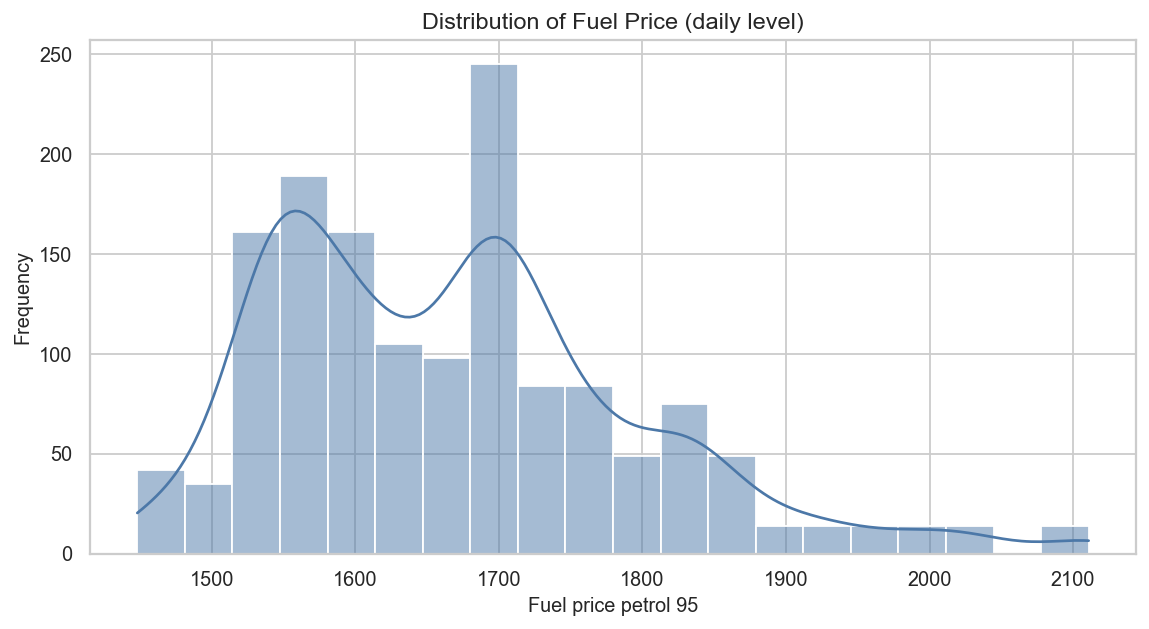

In [ ]:
# -------------------------
# Histogram + KDE (daily-level)
# -------------------------
plt.figure(figsize=(9, 5))
sns.histplot(
    fuel_daily_nonmissing["FuelPrice"],
    bins=20,
    kde=True,
    color="#4C78A8"
)
plt.title("Distribution of Fuel Price (daily level)")
plt.xlabel("Fuel price petrol 95")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(eda_folder / "fuelprice_distribution_daily_hist.png", bbox_inches="tight")
plt.show()
plt.close()

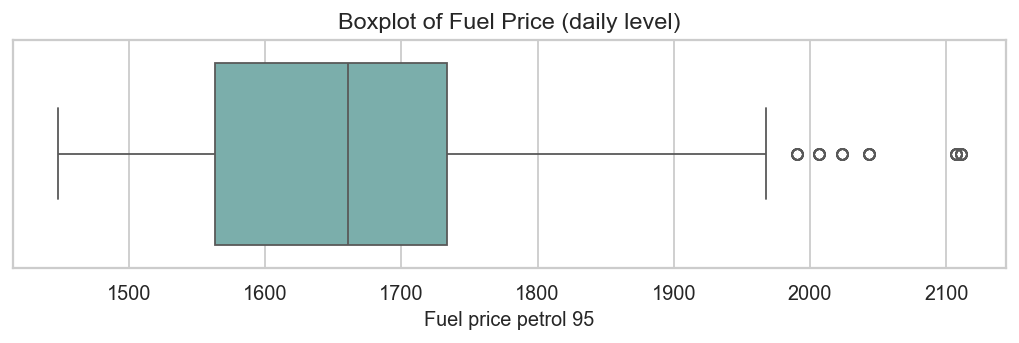

In [ ]:
# -------------------------
# Box plot (daily-level)
# -------------------------
plt.figure(figsize=(8, 2.8))
sns.boxplot(
    x=fuel_daily_nonmissing["FuelPrice"],
    color="#72B7B2",
    showfliers=True
)
plt.title("Boxplot of Fuel Price (daily level)")
plt.xlabel("Fuel price petrol 95")
plt.tight_layout()
plt.savefig(eda_folder / "fuelprice_distribution_daily_boxplot.png", bbox_inches="tight")
plt.show()
plt.close()

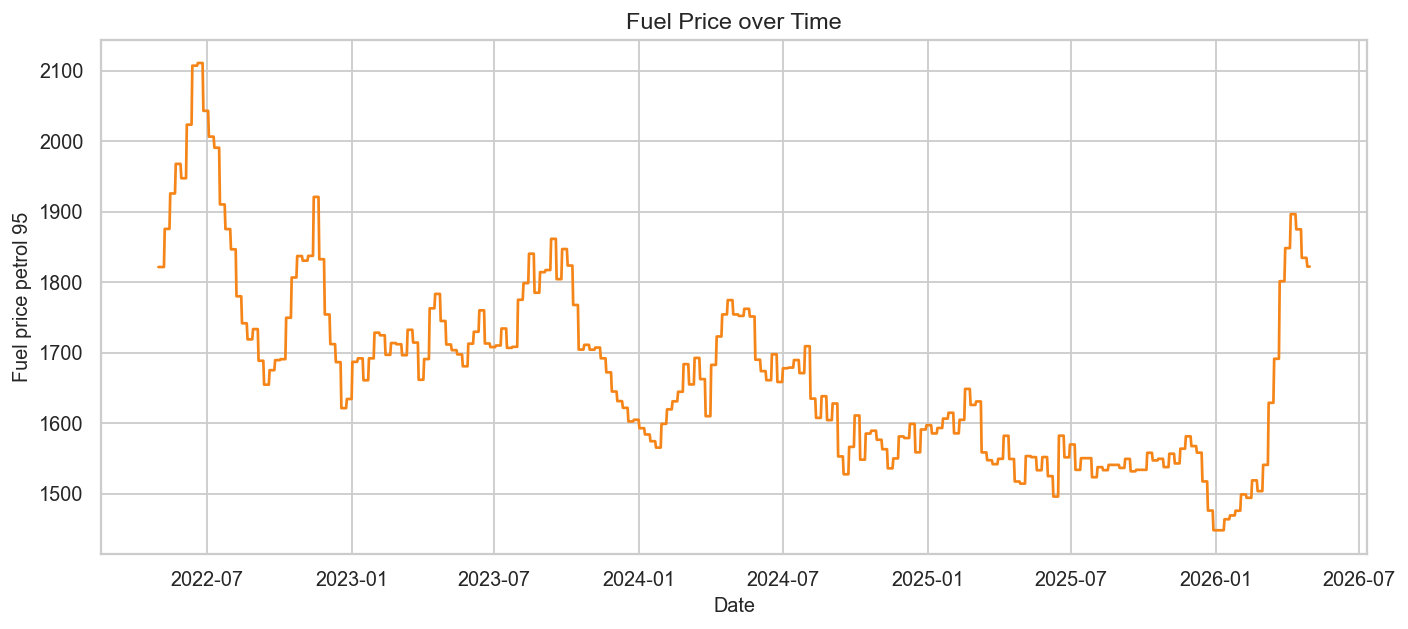

In [ ]:
# -------------------------
# Time-series plot
# -------------------------
plt.figure(figsize=(11, 5))
sns.lineplot(
    data=fuel_daily_nonmissing,
    x="date",
    y="FuelPrice",
    color="#F58518"
)
plt.title("Fuel Price over Time")
plt.xlabel("Date")
plt.ylabel("Fuel price petrol 95")
plt.tight_layout()
plt.savefig(eda_folder / "fuelprice_time_series.png", bbox_inches="tight")
plt.show()
plt.close()

In [ ]:
# -------------------------
# Descriptive statistics
# -------------------------
fuel_desc = (
    fuel_daily_nonmissing["FuelPrice"]
    .describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
    .reset_index()
)
fuel_desc.columns = ["statistic", "value"]

fuel_desc.to_csv(eda_folder / "fuelprice_descriptive_stats.csv", index=False)
fuel_desc

,statistic,value
0,count,1461.000000
1,mean,1669.364120
2,std,127.663834
3,min,1448.200000
4,1%,1463.840000
5,5%,1514.330000
6,25%,1563.120000
7,50%,1660.990000
8,75%,1733.500000
9,95%,1910.240000


### Data exploration for response variable (count_rescaled)

In [ ]:
response_var = "count_rescaled"
response_df=df.copy()
response_df["Outcome"] = response_df[response_var]

# -------------------------
# Basic count / completeness summary
# -------------------------
response_count_summary = pd.DataFrame({
    "metric": [
        "total_rows",
        "non_missing_rows",
        "missing_rows",
        "missing_share",
        "zero_rows",
        "zero_share",
        "unique_values"
    ],
    "value": [
        len(response_df),
        response_df["Outcome"].notna().sum(),
        response_df["Outcome"].isna().sum(),
        response_df["Outcome"].isna().mean(),
        (response_df["Outcome"] == 0).sum(),
        (response_df["Outcome"] == 0).mean(),
        response_df["Outcome"].nunique()
    ]
})

response_count_summary.to_csv(eda_folder / "response_count_summary.csv", index=False)
response_count_summary

,metric,value
0,total_rows,4.587736e+06
1,non_missing_rows,4.587736e+06
2,missing_rows,0.000000e+00
3,missing_share,0.000000e+00
4,zero_rows,1.254674e+06
5,zero_share,2.734844e-01
6,unique_values,1.167000e+03


There is missing value in count_rescaled, but many 0 values.

In [ ]:
# -------------------------
# Binned counts table
# -------------------------
n_bins = 30

response_nonmissing = response_df.dropna(subset=["Outcome"]).copy()

response_nonmissing["Outcome_bin"] = pd.cut(
    response_nonmissing["Outcome"],
    bins=n_bins
)

response_bin_counts = (
    response_nonmissing["Outcome_bin"]
    .value_counts(sort=False)
    .rename_axis("Outcome_bin")
    .reset_index(name="n")
)

response_bin_counts["share"] = response_bin_counts["n"] / response_bin_counts["n"].sum()

response_bin_counts.to_csv(eda_folder / "response_binned_counts.csv", index=False)
response_bin_counts

,Outcome_bin,n,share
0,"(-8.682, 289.4]",4560355,9.940317e-01
1,"(289.4, 578.8]",24548,5.350787e-03
2,"(578.8, 868.2]",2498,5.444951e-04
3,"(868.2, 1157.6]",236,5.144150e-05
4,"(1157.6, 1447.0]",40,8.718898e-06
5,"(1447.0, 1736.4]",33,7.193090e-06
6,"(1736.4, 2025.8]",8,1.743780e-06
7,"(2025.8, 2315.2]",4,8.718898e-07
8,"(2315.2, 2604.6]",4,8.718898e-07
9,"(2604.6, 2894.0]",2,4.359449e-07


Most of the observations lower than 289.4, and larges values lead to right-skew.

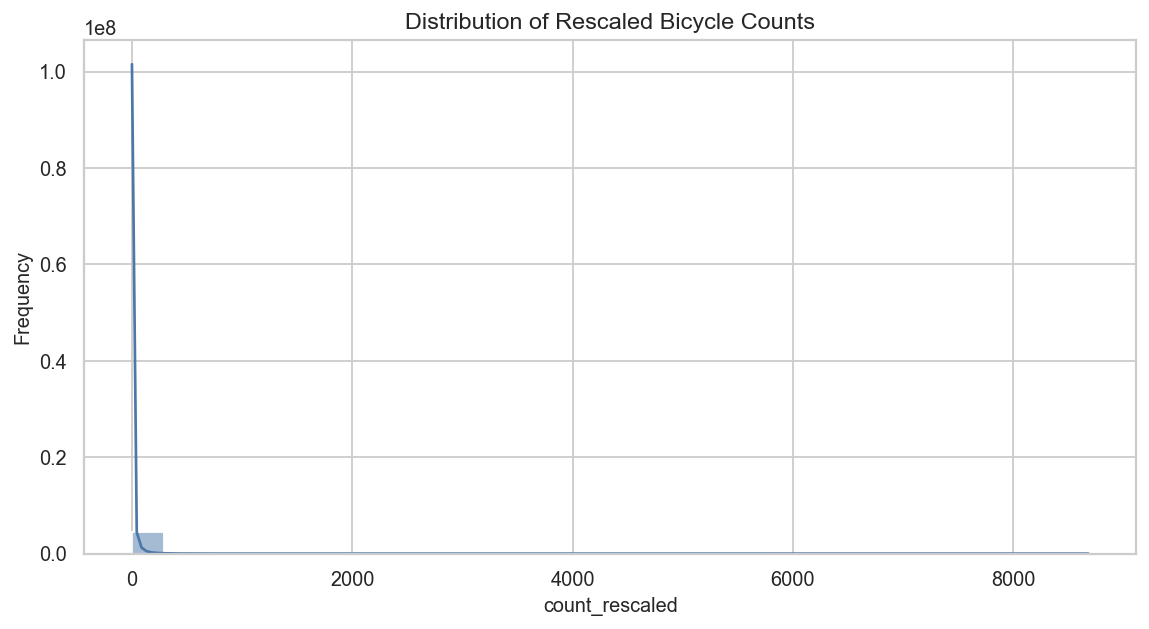

In [ ]:
# -------------------------
# Histogram + KDE
# -------------------------
plt.figure(figsize=(9, 5))
sns.histplot(
    response_nonmissing["Outcome"],
    bins=30,
    kde=True,
    color="#4C78A8"
)
plt.title("Distribution of Rescaled Bicycle Counts")
plt.xlabel("count_rescaled")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(eda_folder / "response_distribution_hist.png", bbox_inches="tight")
plt.show()
plt.close()

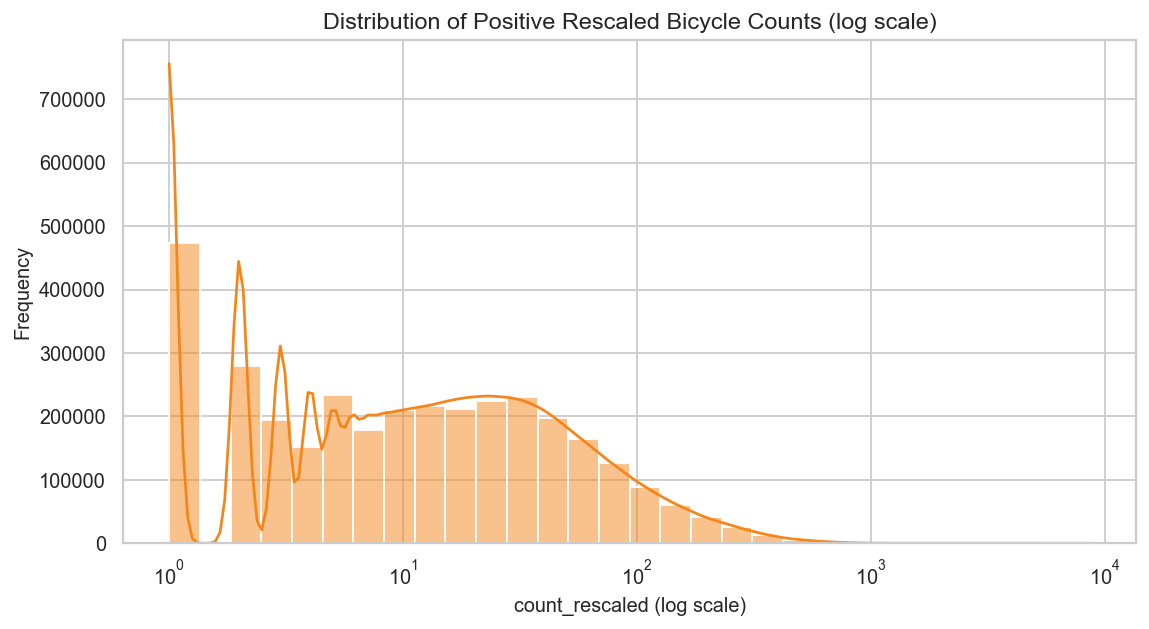

In [ ]:
# -------------------------
# log-scale histogram
# -------------------------
response_positive = response_nonmissing[response_nonmissing["Outcome"] > 0].copy()

plt.figure(figsize=(9, 5))
sns.histplot(
    response_positive["Outcome"],
    bins=30,
    kde=True,
    color="#F58518",
    log_scale=True
)
plt.title("Distribution of Positive Rescaled Bicycle Counts (log scale)")
plt.xlabel("count_rescaled (log scale)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(eda_folder / "response_distribution_hist_logscale.png", bbox_inches="tight")
plt.show()
plt.close()

In [ ]:
# -------------------------
# Descriptive statistics
# -------------------------
response_desc = (
    response_nonmissing["Outcome"]
    .describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
    .reset_index()
)
response_desc.columns = ["statistic", "value"]

response_desc.to_csv(eda_folder / "response_descriptive_stats.csv", index=False)
response_desc

,statistic,value
0,count,4.587736e+06
1,mean,2.135952e+01
2,std,4.899167e+01
3,min,0.000000e+00
4,1%,0.000000e+00
5,5%,0.000000e+00
6,25%,0.000000e+00
7,50%,4.000000e+00
8,75%,2.100000e+01
9,95%,9.600000e+01
